In [ ]:
import pandas as pd

predictions = pd.read_csv("../../out/old/unmodified/predictions.csv")
predictions.head()

In [ ]:
import matplotlib.pyplot as plt

label_counts = predictions['label'].value_counts().sort_values()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Class Distribution in Predictions')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [ ]:
import numpy as np

splits = predictions['split'].unique()
splits.sort()
classes = predictions['label'].unique()
label_per_class = {}

for split in splits:
    split_data = predictions[predictions['split'] == split]
    label_counts = split_data['label'].value_counts().sort_values()
    label_per_class[split] = label_counts

x = np.arange(len(classes))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in label_per_class.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xticks(x + width, classes)
ax.legend(loc='upper left', ncols=1)
ax.set_ylim(0, 6000)

plt.show()

In [ ]:
cm_values = pd.read_csv("../out/unmodified/prepared_data_all.csv")
cm_values.head()

In [ ]:
import os
from per_dataset_analysis.plotting_util import extract_classes

file = "prepared_data_all.csv"
modality = 'unmodified'
metric = 'f1'
out_path = os.path.join("../out", metric, modality)

path = os.path.join("../out", modality, file)
data: pd.DataFrame = pd.read_csv(path)

class_data = extract_classes(data)

In [ ]:
import pandas as pd
import os
data_nejm = pd.read_parquet(os.path.join("../..", "data", "Marine", "batch_0000.parquet"))
data_nejm.head()

In [ ]:
data_nejm = pd.read_parquet(os.path.join("../..", "data", "Marine", "train_000-00000-of-00001.parquet"))
data_nejm.head()

In [1]:
import pandas as pd
import os
data_house = pd.read_csv(os.path.join("../..", "data", "HomePrice", "austinHousingData.csv"))
data_house.head()

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [2]:
data_house.drop(columns=['zpid'], inplace=True)
desc_cols = [c for c in data_house.columns if c not in ['homeImage', 'latestPrice']]

def make_description(row):
    parts = []
    for c in desc_cols:
        v = row[c]
        if pd.isna(v):
            continue
        parts.append(f"{c}: {v}")
    return "; ".join(parts)

result = pd.DataFrame({
    'homeImage': data_house['homeImage'],
    'description': data_house.apply(make_description, axis=1),
    'price': data_house['latestPrice']
})

result.head()

,homeImage,description,price
0,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...,city: pflugerville; streetAddress: 14424 Lake ...,305000.0
1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...,city: pflugerville; streetAddress: 1104 Strick...,295000.0
2,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...,city: pflugerville; streetAddress: 1408 Fort D...,256125.0
3,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...,city: pflugerville; streetAddress: 1025 Strick...,240000.0
4,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg,city: pflugerville; streetAddress: 15005 Donna...,239900.0


count    1.517100e+04
mean     5.127677e+05
std      4.531853e+05
min      5.500000e+03
25%      3.090000e+05
50%      4.050000e+05
75%      5.750000e+05
max      1.350000e+07
Name: price, dtype: float64


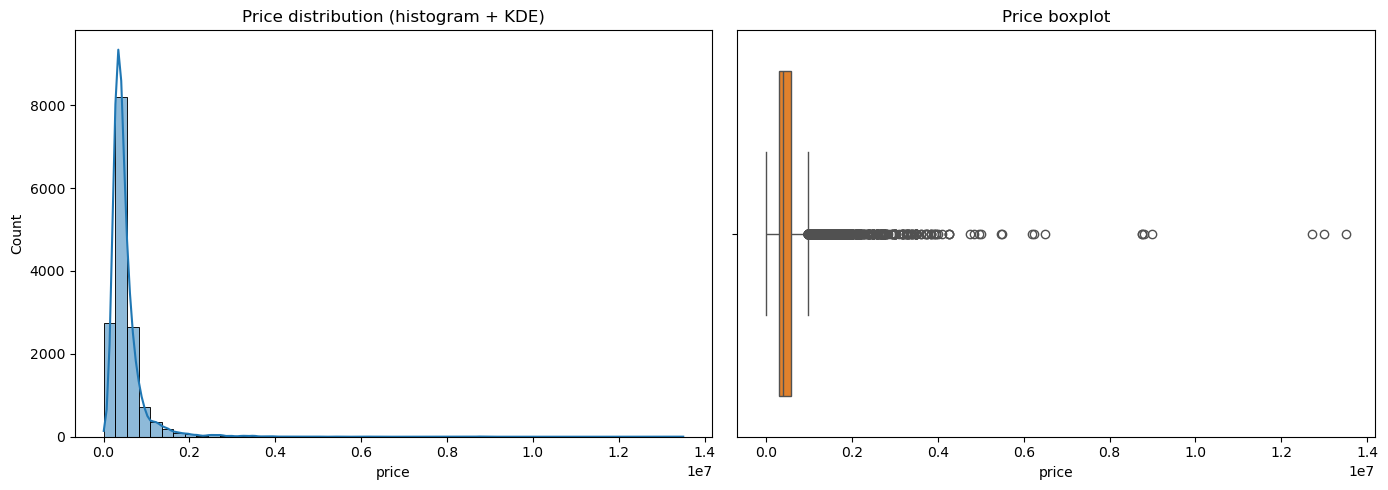

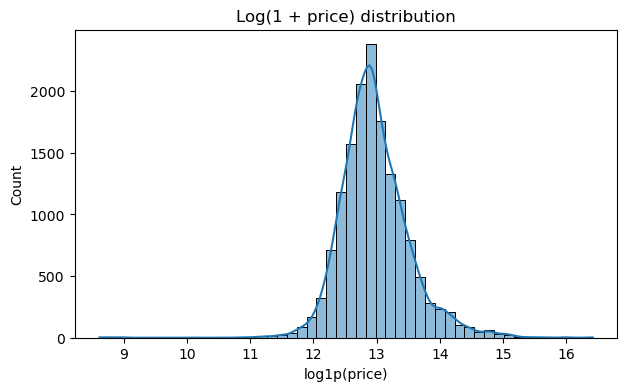

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# assume `result` is available
s = result['price'].copy()

# coerce to numeric if needed (removes currency symbols/commas)
if s.dtype == object:
    s = s.replace(r'[^0-9\.\-]', '', regex=True)
s = pd.to_numeric(s, errors='coerce').dropna()

# print basic statistics
print(s.describe())

# plot histogram + KDE and a boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(s, kde=True, bins=50, ax=axes[0], color='tab:blue')
axes[0].set_title('Price distribution (histogram + KDE)')
axes[0].set_xlabel('price')

sns.boxplot(x=s, ax=axes[1], color='tab:orange')
axes[1].set_title('Price boxplot')
axes[1].set_xlabel('price')

plt.tight_layout()

# save plot
out_path = os.path.join("../..", "out", "plots", "price_distribution.png")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=150)
plt.show()

# optional: view log-transformed distribution if data is highly skewed
if s.skew() > 2:
    plt.figure(figsize=(7,4))
    sns.histplot(np.log1p(s), kde=True, bins=50)
    plt.title('Log(1 + price) distribution')
    plt.xlabel('log1p(price)')
    plt.show()

Gaussian target proportions (normalized): [0.0545 0.2442 0.4026 0.2442 0.0545]
Assigned counts per bin: {np.int64(0): 826, np.int64(1): 3705, np.int64(2): 6108, np.int64(3): 3705, np.int64(4): 827}


/var/folders/q6/xp9ntqs504g_7q5mrx26_wdc0000gn/T/ipykernel_43352/1762214296.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_series.index.astype(int), y=counts_series.values, palette='viridis')


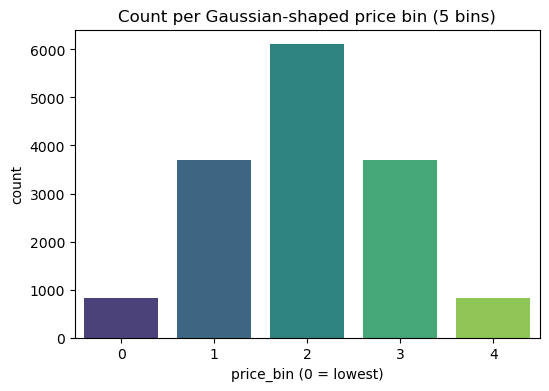

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# assume `result` exists and has a 'price' column
# 1) coerce to numeric (remove non-numeric chars then to_numeric)
prices = result['price'].astype(str).replace(r'[^0-9\.\-]', '', regex=True)
result['price_numeric'] = pd.to_numeric(prices, errors='coerce')

# mask valid numeric prices
valid_mask = result['price_numeric'].notna()
if valid_mask.sum() == 0:
    raise ValueError("No numeric prices found in result['price'] after coercion.")

vals = result.loc[valid_mask, 'price_numeric']
N = len(vals)

# 2) compute Gaussian-shaped proportions for 5 bins
n_bins = 5
z = np.linspace(-2.0, 2.0, n_bins)  # symmetric centers (approx -2..2 sigma)
pdf = np.exp(-0.5 * z * z)
props = pdf / pdf.sum()

# compute integer counts per bin, robustly adjust to sum to N and avoid empty bins when possible
counts = np.round(props * N).astype(int)
if N >= n_bins:
    # ensure at least 1 per bin
    for i in range(n_bins):
        if counts[i] == 0:
            counts[i] = 1
    # adjust to match N
    diff = N - counts.sum()
    if diff > 0:
        order = np.argsort(-props)
        i = 0
        while diff > 0:
            counts[order[i % n_bins]] += 1
            i += 1
            diff -= 1
    elif diff < 0:
        order = np.argsort(props)  # smallest first
        i = 0
        while diff < 0:
            j = order[i % n_bins]
            if counts[j] > 1:
                counts[j] -= 1
                diff += 1
            i += 1
else:
    # fewer samples than bins: give first N bins one sample
    counts = np.array([1 if i < N else 0 for i in range(n_bins)])

# 3) assign bin labels by sorting prices (so middle-valued prices receive middle bins according to Gaussian counts)
sorted_idx = vals.sort_values().index.to_numpy()
labels_by_index = pd.Series(index=vals.index, dtype='Int64')
pos = 0
for bin_id, c in enumerate(counts):
    if c <= 0:
        continue
    selected = sorted_idx[pos:pos + int(c)]
    labels_by_index.loc[selected] = int(bin_id)
    pos += int(c)

# any remaining (due to rounding) put into last bin
if pos < N:
    remaining = sorted_idx[pos:]
    labels_by_index.loc[remaining] = n_bins - 1

# write bin labels into result; ensure invalid (non-numeric) rows get pd.NA and use nullable Int64 dtype
result.loc[valid_mask, 'price_bin'] = labels_by_index
result.loc[~valid_mask, 'price_bin'] = pd.NA
result['price_bin'] = result['price_bin'].astype('Int64')

# 4) create human readable interval per bin (min..max for each bin)
intervals = {}
for i in range(n_bins):
    members = result.loc[valid_mask & (result['price_bin'] == i), 'price_numeric']
    if len(members) == 0:
        intervals[i] = '[]'
    else:
        intervals[i] = f"[{members.min():.2f} - {members.max():.2f}]"

result.loc[valid_mask, 'price_bin_interval'] = result.loc[valid_mask, 'price_bin'].map(lambda x: intervals.get(int(x), '[]'))

# 5) show counts and a small plot
counts_series = result.loc[valid_mask, 'price_bin'].value_counts(sort=False).sort_index()
print('Gaussian target proportions (normalized):', np.round(props, 4))
print('Assigned counts per bin:', counts_series.to_dict())

plt.figure(figsize=(6,4))
sns.barplot(x=counts_series.index.astype(int), y=counts_series.values, palette='viridis')
plt.xlabel('price_bin (0 = lowest)')
plt.ylabel('count')
plt.title(f'Count per Gaussian-shaped price bin ({n_bins} bins)')
plt.show()

In [ ]:
result.head()

In [5]:
result.price_bin_interval.value_counts()

price_bin_interval
[325000.00 - 525000.00]       6108
[205180.00 - 325000.00]       3705
[525000.00 - 1100000.00]      3705
[1100000.00 - 13500000.00]     827
[5500.00 - 205000.00]          826
Name: count, dtype: int64

In [ ]:
result.to_csv('../../data/HomePrice/data_price_binned.csv', index=False)

In [12]:
vox_data = pd.read_csv("../../data/VoxCeleb2/speaker_information.csv")
vox_data.nationality_wiki.unique()

array(['Germany', 'Canada', 'The-United-Kingdom-1', 'India', 'Australia',
       'The-United-States-of-America', 'Honduras',
       'The-Republic-of-Ireland', 'Jordan-215', 'Switzerland',
       'Kingdom-of-the-Netherlands', 'Austria', 'Spain', 'Slovenia', nan,
       'Belgium', 'Israel', 'Serbia', 'Panama', 'France', 'Cuba',
       'Morocco', 'Soviet-Union-1', 'Sweden', 'Denmark', 'Norway',
       'Russia', 'Chile', 'Greece', 'Georgia-country', 'Brazil',
       'Malaysia', 'Italy', 'Mexico', 'Croatia', 'Indonesia',
       'The-Czech-Republic-1', 'Jamaica', 'Turkey-country', 'Poland',
       'Portugal', 'Iran', 'China', 'Yugoslavia', 'Puerto-Rico', 'Japan',
       'South-Africa', 'Sri-Lanka', 'Colombia', 'Bosnia-and-Herzegovina',
       'Uruguay', 'Angola', 'New-Zealand', 'Hong-Kong', 'Finland',
       'South-Korea', 'Luxembourg', 'The-Philippines-1',
       'British-Colonial-Rule', 'Taiwan', 'Malta', 'Haiti',
       'Dominican-Republic', 'German-Democratic-Republic-DDR', 'Monaco',
   